## **Exercise 04 : Histogram**

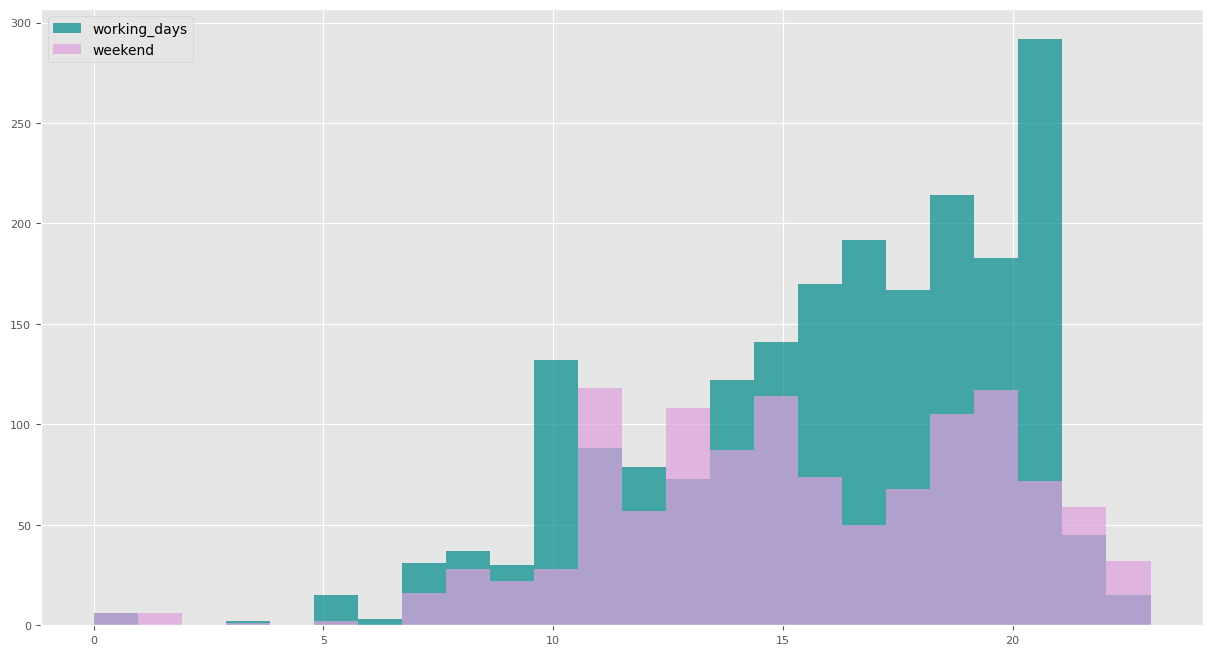

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

connection = sqlite3.connect('../data/checking-logs.sqlite')
commits = pd.read_sql('select timestamp as commits from checker where uid like "%user_%"', connection)
commits[['date', 'hour']] = commits['commits'].apply(lambda x: pd.Series([i for i in x.split()]))

days = pd.date_range(commits['date'].min(), commits['date'].max())
working = days[days.dayofweek < 5]
week_end = days[days.dayofweek >= 5]

commits['date'] = pd.to_datetime(commits['date'])
commits['hour'] = pd.to_datetime(commits['hour'], format="%H:%M:%S.%f").dt.hour
working_day = commits.loc[commits['date'].isin(working)]
weekend = commits.loc[commits['date'].isin(week_end)]

plt.style.use('ggplot')
fig, ax1 = plt.subplots(figsize=(15, 8))
working_day.plot.hist(ax = ax1, bins=24, fontsize=8, color='darkcyan', alpha=0.7)
weekend.plot.hist(ax = ax1, bins=24, fontsize=8, color='plum', alpha=0.7)
ax1.legend(['working_days', 'weekend'], loc="upper left")
ax1.set_ylabel("")
plt.show()

In [2]:
connection.close()

In [3]:
out = []
for x in [weekend, working_day]:
    x = x.groupby(['date',], observed=False)['hour'].value_counts()
    x = x.to_frame().unstack()
    x.columns = x.columns.droplevel(0)
    x = x.describe().loc['mean'] * x.describe().loc['count']
    out.append(x)

ans = pd.concat([out[0], out[1]], axis=1)
ans = ans.loc[ans[0]>ans[1]].index

print(f'Are there hours when the total number of commits was higher on weekends than on working days?\n\
Answer: {list([int(x) for x in ans.values])}')

Are there hours when the total number of commits was higher on weekends than on working days?
Answer: [11, 13, 22, 23]
